In [2]:
import os
import random
from collections import deque, Counter

import numpy as np
import PIL
import PIL.ImageDraw
import matplotlib.pyplot as plt


In [3]:
# Gymnasium
from gymnasium import Env
from gymnasium.spaces import Discrete, Box

# Stable-Baselines3
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback

# The 12 quarter-turn moves (clockwise + counter-clockwise for each face).
# Defined once here and reused by the cube, the env and the analysis tools.
MOVES = ["F", "R", "U", "B", "L", "D", "F'", "R'", "U'", "B'", "L'", "D'"]


In [ ]:
class RubkisCube:
    """A 3x3 Rubik's cube stored as 6 faces of 3x3 stickers.

    The move mechanics (`rotate`) are verified correct: move^4 == identity,
    move . move' == identity, scramble+reverse round-trips, and every color
    always appears exactly 9 times.
    """

    def __init__(self, moves_nr=10, rng=None):
        # A dedicated RNG (instead of the global `random`) makes scrambles
        # reproducible per-environment, which matters for benchmarking.
        self.rng = rng if rng is not None else random.Random()
        self.scramble_moves = []
        self.cube = {"U": [['W', 'W', 'W'], ['W', 'W', 'W'], ['W', 'W', 'W']],
            "L": [['O', 'O', 'O'], ['O', 'O', 'O'], ['O', 'O', 'O']],
            "F": [['G', 'G', 'G'], ['G', 'G', 'G'], ['G', 'G', 'G']],
            "R": [['R', 'R', 'R'], ['R', 'R', 'R'], ['R', 'R', 'R']],
            "B": [['B', 'B', 'B'], ['B', 'B', 'B'], ['B', 'B', 'B']],
            "D": [['Y', 'Y', 'Y'], ['Y', 'Y', 'Y'], ['Y', 'Y', 'Y']]
        }
        self.shuffle(moves_nr)

    def __str__(self):
        string = ""
        for face in self.cube.values():
            for row in face:
                for square in row:
                    string += square
        return string

    def get_color(self, color: str):
        return {"R": (255, 0, 0), "G": (0, 255, 0), "B": (0, 0, 255),
                "W": (255, 255, 255), "Y": (255, 255, 0),
                "O": (255, 128, 0)}[color]

    def draw_cube(self):
        square_size = 50
        im = PIL.Image.new(mode="RGB", size=(square_size * 12, square_size * 9),
                           color=(30, 30, 30))
        draw = PIL.ImageDraw.Draw(im)

        positions = {"U": (3, 0), "L": (0, 3), "F": (3, 3),
                     "R": (6, 3), "B": (9, 3), "D": (3, 6)}

        for side, pos in positions.items():
            base_x, base_y = pos[0] * square_size, pos[1] * square_size
            for row in range(3):
                for col in range(3):
                    color = self.get_color(self.cube[side][row][col])
                    x1 = base_x + (col * square_size)
                    y1 = base_y + (row * square_size)
                    draw.rectangle(xy=(x1, y1, x1 + square_size, y1 + square_size),
                                   fill=color, outline=(0, 0, 0))
        return im

    def rotate(self, move: str):
        face = move[0]
        direction = "CCW" if "'" in move else "CW"

        old_face = [row[:] for row in self.cube[face]]
        for i in range(3):
            for j in range(3):
                if direction == "CW":
                    self.cube[face][j][2 - i] = old_face[i][j]
                elif direction == "CCW":
                    self.cube[face][2 - j][i] = old_face[i][j]

        if face == "U":
            if direction == "CW":
                temp = self.cube["L"][0][:]
                self.cube["L"][0] = self.cube["F"][0][:]
                self.cube["F"][0] = self.cube["R"][0][:]
                self.cube["R"][0] = self.cube["B"][0][:]
                self.cube["B"][0] = temp
            elif direction == "CCW":
                temp = self.cube["L"][0][:]
                self.cube["L"][0] = self.cube["B"][0][:]
                self.cube["B"][0] = self.cube["R"][0][:]
                self.cube["R"][0] = self.cube["F"][0][:]
                self.cube["F"][0] = temp

        elif face == "D":
            if direction == "CW":
                temp = self.cube["L"][2][:]
                self.cube["L"][2] = self.cube["B"][2][:]
                self.cube["B"][2] = self.cube["R"][2][:]
                self.cube["R"][2] = self.cube["F"][2][:]
                self.cube["F"][2] = temp
            elif direction == "CCW":
                temp = self.cube["L"][2][:]
                self.cube["L"][2] = self.cube["F"][2][:]
                self.cube["F"][2] = self.cube["R"][2][:]
                self.cube["R"][2] = self.cube["B"][2][:]
                self.cube["B"][2] = temp

        elif face == "F":
            if direction == "CW":
                temp = self.cube["U"][2][:]
                self.cube["U"][2] = [self.cube["L"][2][2], self.cube["L"][1][2], self.cube["L"][0][2]]
                self.cube["L"][0][2], self.cube["L"][1][2], self.cube["L"][2][2] = self.cube["D"][0][:]
                self.cube["D"][0] = [self.cube["R"][2][0], self.cube["R"][1][0], self.cube["R"][0][0]]
                self.cube["R"][0][0], self.cube["R"][1][0], self.cube["R"][2][0] = temp
            elif direction == "CCW":
                temp = self.cube["U"][2][:]
                self.cube["U"][2] = [self.cube["R"][0][0], self.cube["R"][1][0], self.cube["R"][2][0]]
                self.cube["R"][0][0], self.cube["R"][1][0], self.cube["R"][2][0] = self.cube["D"][0][::-1]
                self.cube["D"][0] = [self.cube["L"][0][2], self.cube["L"][1][2], self.cube["L"][2][2]]
                self.cube["L"][0][2], self.cube["L"][1][2], self.cube["L"][2][2] = temp[::-1]

        elif face == "B":
            if direction == "CW":
                temp = self.cube["U"][0][:]
                self.cube["U"][0] = [self.cube["R"][0][2], self.cube["R"][1][2], self.cube["R"][2][2]]
                self.cube["R"][0][2], self.cube["R"][1][2], self.cube["R"][2][2] = self.cube["D"][2][::-1]
                self.cube["D"][2] = [self.cube["L"][0][0], self.cube["L"][1][0], self.cube["L"][2][0]]
                self.cube["L"][0][0], self.cube["L"][1][0], self.cube["L"][2][0] = temp[::-1]
            elif direction == "CCW":
                temp = self.cube["U"][0][:]
                self.cube["U"][0] = [self.cube["L"][2][0], self.cube["L"][1][0], self.cube["L"][0][0]]
                self.cube["L"][0][0], self.cube["L"][1][0], self.cube["L"][2][0] = self.cube["D"][2][:]
                self.cube["D"][2] = [self.cube["R"][2][2], self.cube["R"][1][2], self.cube["R"][0][2]]
                self.cube["R"][0][2], self.cube["R"][1][2], self.cube["R"][2][2] = temp

        elif face == "L":
            if direction == "CW":
                temp = [self.cube["U"][i][0] for i in range(3)]
                for i in range(3): self.cube["U"][i][0] = self.cube["B"][2 - i][2]
                for i in range(3): self.cube["B"][i][2] = self.cube["D"][2 - i][0]
                for i in range(3): self.cube["D"][i][0] = self.cube["F"][i][0]
                for i in range(3): self.cube["F"][i][0] = temp[i]
            elif direction == "CCW":
                temp = [self.cube["U"][i][0] for i in range(3)]
                for i in range(3): self.cube["U"][i][0] = self.cube["F"][i][0]
                for i in range(3): self.cube["F"][i][0] = self.cube["D"][i][0]
                for i in range(3): self.cube["D"][i][0] = self.cube["B"][2 - i][2]
                for i in range(3): self.cube["B"][i][2] = temp[2 - i]

        elif face == "R":
            if direction == "CW":
                temp = [self.cube["U"][i][2] for i in range(3)]
                for i in range(3): self.cube["U"][i][2] = self.cube["F"][i][2]
                for i in range(3): self.cube["F"][i][2] = self.cube["D"][i][2]
                for i in range(3): self.cube["D"][i][2] = self.cube["B"][2 - i][0]
                for i in range(3): self.cube["B"][i][0] = temp[2 - i]
            elif direction == "CCW":
                temp = [self.cube["U"][i][2] for i in range(3)]
                for i in range(3): self.cube["U"][i][2] = self.cube["B"][2 - i][0]
                for i in range(3): self.cube["B"][i][0] = self.cube["D"][2 - i][2]
                for i in range(3): self.cube["D"][i][2] = self.cube["F"][i][2]
                for i in range(3): self.cube["F"][i][2] = temp[i]

    def shuffle(self, moves=50):
        faces = ["F", "R", "U", "B", "L", "D"]
        seq = []
        prev_face = None
        for _ in range(moves):
            face = self.rng.choice([f for f in faces if f != prev_face])
            move = face + self.rng.choice(["", "'"])
            self.rotate(move)
            seq.append(move)
            prev_face = face
        self.scramble_moves = seq
        return self

    def check_score(self):
        return sum(sum(row.count(face[1][1]) for row in face)
                   for face in self.cube.values())

    def check_done(self):
        return self.check_score() == 54

    def step(self, action):
        self.rotate(MOVES[action])
        return self.check_score()


# Building the Environment

In [ ]:
class CubeEnv(Env):
    """
    Gymnasium environment wrapping RubkisCube.
    """

    metadata = {"render_modes": ["rgb_array"]}

    COLOR_TO_IDX = {'W': 0, 'O': 1, 'G': 2, 'R': 3, 'B': 4, 'Y': 5}
    N_STICKERS = 54
    N_COLORS = 6

    def __init__(self, scramble_depth=1, max_moves=None,
                 solve_reward=10.0, progress_scale=0.2, step_penalty=-0.1):
        self.action_space = Discrete(len(MOVES))
        self.observation_space = Box(low=0.0, high=1.0,
                                     shape=(self.N_STICKERS * self.N_COLORS,),
                                     dtype=np.float32)

        self.scramble_depth = int(scramble_depth)
        self._max_moves_override = max_moves

        self.solve_reward = solve_reward
        self.progress_scale = progress_scale
        self.step_penalty = step_penalty

        self._rng = random.Random()
        self.state = None
        self.moves_left = 0
        self.previous_score = 0

    def set_difficulty(self, scramble_depth, max_moves=None):
        self.scramble_depth = int(scramble_depth)
        self._max_moves_override = max_moves

    def _effective_max_moves(self):
        if self._max_moves_override is not None:
            return self._max_moves_override
        return self.scramble_depth * 2 + 5

    def _state_to_observation(self):
        idx = np.fromiter((self.COLOR_TO_IDX[c] for c in str(self.state)),
                          dtype=np.int64, count=self.N_STICKERS)
        onehot = np.zeros((self.N_STICKERS, self.N_COLORS), dtype=np.float32)
        onehot[np.arange(self.N_STICKERS), idx] = 1.0
        return onehot.reshape(-1)

    def _calculate_reward(self, current_score, terminated):
        if terminated:
            return self.solve_reward
        improvement = current_score - self.previous_score
        return improvement * self.progress_scale + self.step_penalty

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng.seed(seed)

        self.state = RubkisCube(moves_nr=max(1, self.scramble_depth), rng=self._rng)
        self.moves_left = self._effective_max_moves()
        self.previous_score = self.state.check_score()
        return self._state_to_observation(), {}

    def step(self, action):
        current_score = self.state.step(int(action))
        self.moves_left -= 1

        terminated = current_score == self.N_STICKERS       # solved
        truncated = (not terminated) and self.moves_left == 0

        reward = self._calculate_reward(current_score, terminated)
        self.previous_score = current_score

        info = {
            'moves_remaining': self.moves_left,
            'score': current_score,
            'completion_percentage': (current_score / self.N_STICKERS) * 100,
            'is_solved': terminated,
        }
        return self._state_to_observation(), reward, terminated, truncated, info

    def render(self):
        return self.state.draw_cube()


# Validate the Environment

`check_env` confirms the env obeys the Gymnasium API, then we run a random-action rollout as a sanity check.

In [ ]:
check_env(CubeEnv(scramble_depth=3), warn=True)
print("check_env passed.")


check_env passed.


In [ ]:
env_cub_test = CubeEnv(scramble_depth=5)
obs, info = env_cub_test.reset(seed=0)

done = False
total_reward = 0.0
while not done:
    action = env_cub_test.action_space.sample()
    obs, reward, terminated, truncated, info = env_cub_test.step(action)
    total_reward += reward
    done = terminated or truncated

print(f"episode reward: {total_reward:.2f} | solved: {info['is_solved']} | "
      f"final score: {info['score']}/54")
del env_cub_test, obs, info, done, total_reward, action, reward, terminated, truncated


episode reward: -3.10 | solved: False | final score: 12/54


# Curriculum Learning

Solving a deep scramble from scratch with a sparse-ish reward is extremely hard. Instead we start at 1-move scrambles and automatically increase the scramble depth once the agent reliably solves the current depth. The callback also logs `curriculum/scramble_depth` and `rollout/solve_rate` to TensorBoard so you can watch progress.

In [ ]:
class CurriculumCallback(BaseCallback):
    """
    Deepen the scramble as the agent's solve-rate at the current depth rises.
    """

    def __init__(self, start_depth=1, max_depth=20, window=200,
                 promote_threshold=0.85, verbose=1):
        super().__init__(verbose)
        self.depth = start_depth
        self.max_depth = max_depth
        self.window = window
        self.promote_threshold = promote_threshold
        self.results = deque(maxlen=window)

    def _on_training_start(self):
        self.training_env.env_method("set_difficulty", self.depth)

    def _on_step(self):
        for done, info in zip(self.locals["dones"], self.locals["infos"]):
            if done:
                self.results.append(1.0 if info.get("is_solved", False) else 0.0)

        if len(self.results) == self.window:
            solve_rate = sum(self.results) / self.window
            self.logger.record("rollout/solve_rate", solve_rate)
            if solve_rate >= self.promote_threshold and self.depth < self.max_depth:
                self.depth += 1
                self.training_env.env_method("set_difficulty", self.depth)
                self.results.clear()
                if self.verbose:
                    print(f"[curriculum] solve_rate={solve_rate:.2f} -> "
                          f"promoting to scramble_depth={self.depth}")

        self.logger.record("curriculum/scramble_depth", self.depth)
        return True


# Train Model

In [ ]:
log_path = os.path.join('Training', 'Logs')
cube_model_path = os.path.join('Training', 'Saved Models', 'Cube_Model')

N_ENVS = 8
vec_env = make_vec_env(CubeEnv, n_envs=N_ENVS, env_kwargs=dict(scramble_depth=1))


In [10]:
# device='cpu' is intentional: SB3 recommends CPU for small MLP policies.
model = PPO(
    'MlpPolicy', vec_env,
    verbose=1,
    tensorboard_log=log_path,
    device='cpu',
    n_steps=2048,
    batch_size=512,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    learning_rate=3e-4,
    policy_kwargs=dict(net_arch=[256, 256]),
)


Using cpu device


In [ ]:
curriculum = CurriculumCallback(start_depth=1, max_depth=20,
                                window=200, promote_threshold=0.85)

model.learn(total_timesteps=5_000_000, callback=curriculum,
            progress_bar=True)

Cleared the output of this cell. Here are the last few outputs:

-----------------------------------------
| curriculum/             |             |
|    scramble_depth       | 6           |
| rollout/                |             |
|    ep_len_mean          | 10.1        |
|    ep_rew_mean          | 8.76        |
|    solve_rate           | 0.73        |
| time/                   |             |
|    fps                  | 1844        |
|    iterations           | 303         |
|    time_elapsed         | 2690        |
|    total_timesteps      | 4964352     |
| train/                  |             |
|    approx_kl            | 0.049256697 |
|    clip_fraction        | 0.233       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.561      |
|    explained_variance   | 0.66        |
|    learning_rate        | 0.0003      |
|    loss                 | 1.78        |
|    n_updates            | 3020        |
|    policy_gradient_loss | -0.0402     |
|    value_

In [12]:
model.save(cube_model_path)
print("saved model to", cube_model_path)


saved model to Training\Saved Models\Cube_Model


# Evaluating the Model

Load the trained model and measure real performance. Mean reward (`evaluate_policy`) is only a proxy — the metric that actually matters is **solve rate** at a given scramble depth, so we measure that directly and compare against a random baseline.

In [13]:
# Fresh env for evaluation (single, non-vectorized).
eval_env = CubeEnv(scramble_depth=5)
model_2 = PPO.load(cube_model_path, env=eval_env)

# Sanity check: mean reward +/- std over 10 episodes.
mean_r, std_r = evaluate_policy(model_2, eval_env, n_eval_episodes=10)
print(f"evaluate_policy: mean reward {mean_r:.2f} +/- {std_r:.2f}")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
evaluate_policy: mean reward 10.38 +/- 6.87


c:\Users\Redward\.conda\envs\second_env\lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


In [14]:
def evaluate_solve_rate(agent, scramble_depth, n_episodes=200,
                        deterministic=True, seed=0):
    """Run `agent` on freshly scrambled cubes and report how often it solves them.

    Returns a dict with solve_rate, average solution length (over solved cubes),
    average episode reward, and the raw list of solution lengths.
    """
    env = CubeEnv(scramble_depth=scramble_depth)
    solved, lengths, rewards = 0, [], []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        done, ep_reward, steps = False, 0.0, 0
        while not done:
            action, _ = agent.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(int(action))
            ep_reward += reward
            steps += 1
            done = terminated or truncated
        rewards.append(ep_reward)
        if info["is_solved"]:
            solved += 1
            lengths.append(steps)
    return {
        "scramble_depth": scramble_depth,
        "solve_rate": solved / n_episodes,
        "avg_solve_len": (sum(lengths) / len(lengths)) if lengths else float("nan"),
        "avg_reward": sum(rewards) / n_episodes,
        "n_solved": solved,
        "n_episodes": n_episodes,
        "solve_lengths": lengths,
    }


class RandomAgent:
    """Uniform-random baseline with the same .predict() interface as an SB3 model."""
    def __init__(self, action_space):
        self.action_space = action_space
    def predict(self, obs, deterministic=True):
        return self.action_space.sample(), None


In [15]:
# Benchmark solve-rate vs scramble depth: trained model vs random baseline.
depths = list(range(1, 11))
random_agent = RandomAgent(eval_env.action_space)

model_results = [evaluate_solve_rate(model_2, d, n_episodes=100) for d in depths]
random_results = [evaluate_solve_rate(random_agent, d, n_episodes=100) for d in depths]

print(f"{'depth':>5} | {'PPO solve%':>10} | {'PPO len':>8} | {'random solve%':>13}")
print("-" * 46)
for d, m, r in zip(depths, model_results, random_results):
    print(f"{d:>5} | {m['solve_rate']*100:>9.1f}% | {m['avg_solve_len']:>8.2f} | "
          f"{r['solve_rate']*100:>12.1f}%")


depth | PPO solve% |  PPO len | random solve%
----------------------------------------------
    1 |     100.0% |     1.00 |          5.0%
    2 |     100.0% |     2.00 |          0.0%
    3 |     100.0% |     2.88 |          0.0%
    4 |     100.0% |     3.84 |          0.0%
    5 |      90.0% |     4.82 |          0.0%
    6 |      72.0% |     5.78 |          0.0%
    7 |      48.0% |     6.62 |          0.0%
    8 |      23.0% |     7.39 |          0.0%
    9 |      12.0% |     7.67 |          0.0%
   10 |       8.0% |     8.50 |          0.0%


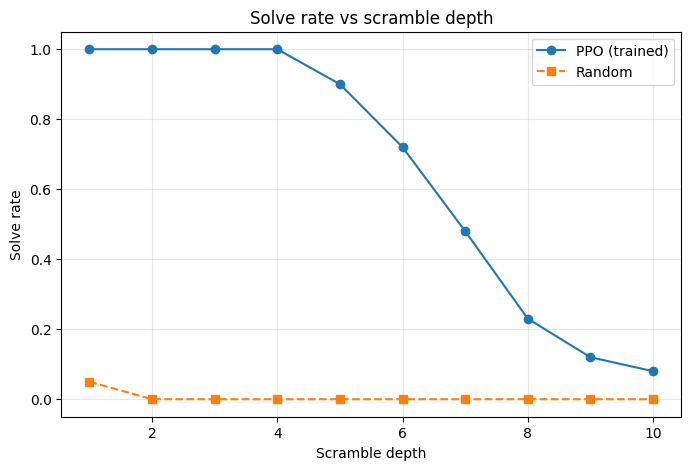

In [16]:
# Plot: solve rate vs scramble depth.
plt.figure(figsize=(8, 5))
plt.plot(depths, [m["solve_rate"] for m in model_results], "o-", label="PPO (trained)")
plt.plot(depths, [r["solve_rate"] for r in random_results], "s--", label="Random")
plt.xlabel("Scramble depth")
plt.ylabel("Solve rate")
plt.ylim(-0.05, 1.05)
plt.title("Solve rate vs scramble depth")
plt.legend()
plt.grid(True, alpha=0.3)
os.makedirs("docs", exist_ok=True)
plt.savefig(os.path.join("docs", "solve_rate.png"), dpi=120, bbox_inches="tight")
plt.show()


depth 6: solve rate 78.0%, avg solution length 5.87


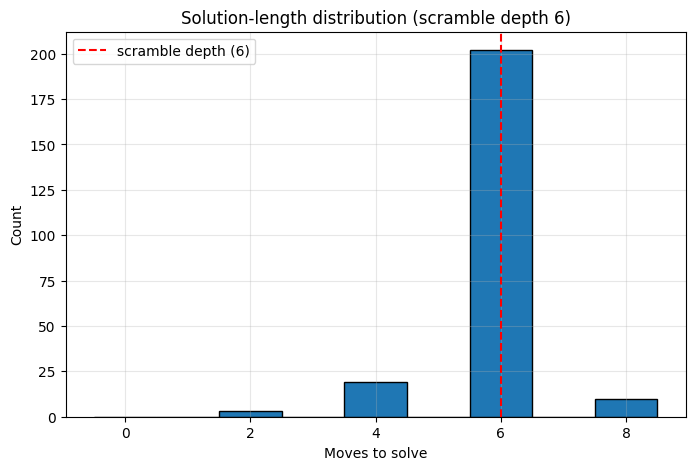

In [17]:
# Distribution of solution lengths at a chosen depth (solved cubes only).
depth_for_hist = 6
res = evaluate_solve_rate(model_2, depth_for_hist, n_episodes=300)
print(f"depth {depth_for_hist}: solve rate {res['solve_rate']*100:.1f}%, "
      f"avg solution length {res['avg_solve_len']:.2f}")

if res["solve_lengths"]:
    plt.figure(figsize=(8, 5))
    plt.hist(res["solve_lengths"],
             bins=range(0, max(res["solve_lengths"]) + 2), align="left",
             edgecolor="black")
    plt.axvline(depth_for_hist, color="red", linestyle="--",
                label=f"scramble depth ({depth_for_hist})")
    plt.xlabel("Moves to solve")
    plt.ylabel("Count")
    plt.title(f"Solution-length distribution (scramble depth {depth_for_hist})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No cubes solved at this depth — nothing to plot.")


scramble : D F' U R D L'
solution (17 moves): R' L U' D' U U' U U' U U' U U' U U' U U' U
did not solve within move budget.
saved animation to docs\solve.gif


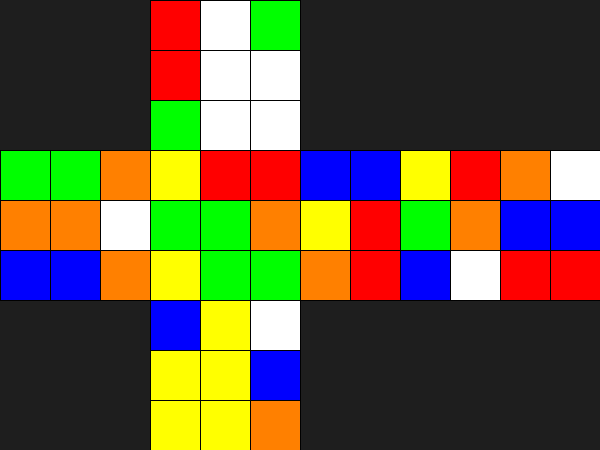

In [18]:
def solve_and_render(agent, scramble_depth=6, deterministic=True,
                     seed=None, save_gif=None):
    """Solve one scrambled cube, print the move sequence, and return the frames.

    If `save_gif` is a path, an animated GIF of the solve is written there.
    """
    env = CubeEnv(scramble_depth=scramble_depth)
    obs, info = env.reset(seed=seed)

    frames = [env.render()]
    moves = []
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=deterministic)
        moves.append(MOVES[int(action)])
        obs, reward, terminated, truncated, info = env.step(int(action))
        frames.append(env.render())
        done = terminated or truncated

    print(f"scramble : {' '.join(env.state.scramble_moves)}")
    print(f"solution ({len(moves)} moves): {' '.join(moves)}")
    print("SOLVED!" if info["is_solved"] else "did not solve within move budget.")

    if save_gif:
        frames[0].save(save_gif, save_all=True, append_images=frames[1:],
                       duration=500, loop=0)
        print("saved animation to", save_gif)
    return frames, moves, info["is_solved"]


# Watch it solve a single cube (returns the final rendered frame in the notebook).
frames, moves, solved = solve_and_render(model_2, scramble_depth=6, seed=42,
                                         save_gif=os.path.join("docs", "solve.gif"))
frames[-1]


### TensorBoard

Watch training curves — including the custom `curriculum/scramble_depth` and `rollout/solve_rate` metrics — by running from the project root:

```
tensorboard --logdir Training/Logs
```